# Notebook 11: Explainable AI using SHAP

## Objective

To interpret the predictions made by the best-performing machine learning model using SHAP (SHapley Additive exPlanations) and identify the genes that contribute most to TNBC classification.


In [ ]:
!pip -q install shap

In [ ]:
import pandas as pd
import numpy as np

import shap
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clinical_matched.csv to clinical_matched.csv


In [ ]:
expression = pd.read_csv(
    "expression_filtered.csv",
    index_col=0
)

clinical = pd.read_csv(
    "clinical_matched.csv"
)

expression.head()

,TCGA-D8-A1JA-01,TCGA-BH-A0BQ-01,TCGA-BH-A0BT-01,TCGA-A8-A06X-01,TCGA-A8-A096-01,TCGA-BH-A0C7-01,TCGA-AR-A0TV-01,TCGA-BH-A18J-01,TCGA-BH-A0W7-01,TCGA-BH-A0HA-01,...,TCGA-D8-A1X6-01,TCGA-BH-A0BL-01,TCGA-BH-A0DO-01,TCGA-A2-A04Q-01,TCGA-E9-A1NI-01,TCGA-AR-A24T-01,TCGA-AO-A0JA-01,TCGA-D8-A1XZ-01,TCGA-E2-A15F-01,TCGA-B6-A0X7-01
Gene,,,,,,,,,,,,,,,,,,,,,
ARHGEF10L,7.4346,9.3216,9.0198,9.6417,9.7665,10.0931,9.6694,9.2718,9.5610,9.8078,...,8.8809,9.5235,10.4995,10.0640,9.7984,8.6545,8.9976,8.5721,10.0334,10.5745
HIF3A,3.6607,2.7224,1.3414,0.5819,0.2738,3.6090,0.4330,2.1682,2.6648,1.9196,...,0.5947,6.2779,3.9977,2.2799,4.2270,0.4028,0.7707,1.5668,0.8836,4.0696
RNF10,11.9181,11.9665,13.1881,12.0036,11.8118,11.3820,11.9378,12.3127,11.9861,12.4059,...,12.1456,11.4204,11.8661,11.7065,12.5475,11.6361,12.0733,11.9794,12.0135,11.8663
RNF11,13.5273,11.4105,11.0911,11.2545,10.8554,10.7663,11.2889,11.2739,10.8410,11.4196,...,11.1187,11.0695,11.1226,10.7574,10.6631,11.1444,11.1703,10.8409,10.8370,10.7644
RNF13,10.8702,10.4406,10.4244,10.1480,10.4282,10.3366,10.6282,9.9904,10.0474,10.4422,...,10.1944,10.0744,10.3785,10.4053,10.6952,10.9800,10.3678,10.5156,10.5614,10.4864


In [ ]:
X = expression.T

clinical["TNBC"] = (
    (clinical["ER_Status_nature2012"] == "Negative")
    &
    (clinical["PR_Status_nature2012"] == "Negative")
    &
    (clinical["HER2_Final_Status_nature2012"] == "Negative")
).astype(int)

y = clinical["TNBC"]

print(X.shape)
print(y.shape)

(744, 17030)
(744,)


In [ ]:
print(X.shape)
print(y.shape)

(744, 17030)
(744,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(595, 17030)
(149, 17030)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
import joblib

joblib.dump(rf, "RandomForest_Model.pkl")

['RandomForest_Model.pkl']

In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

In [ ]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("List")
    print(shap_values[0].shape)
    print(shap_values[1].shape)
else:
    print("Array")
    print(shap_values.shape)

print(X_test.shape)

<class 'numpy.ndarray'>
Array
(149, 17030, 2)
(149, 17030)


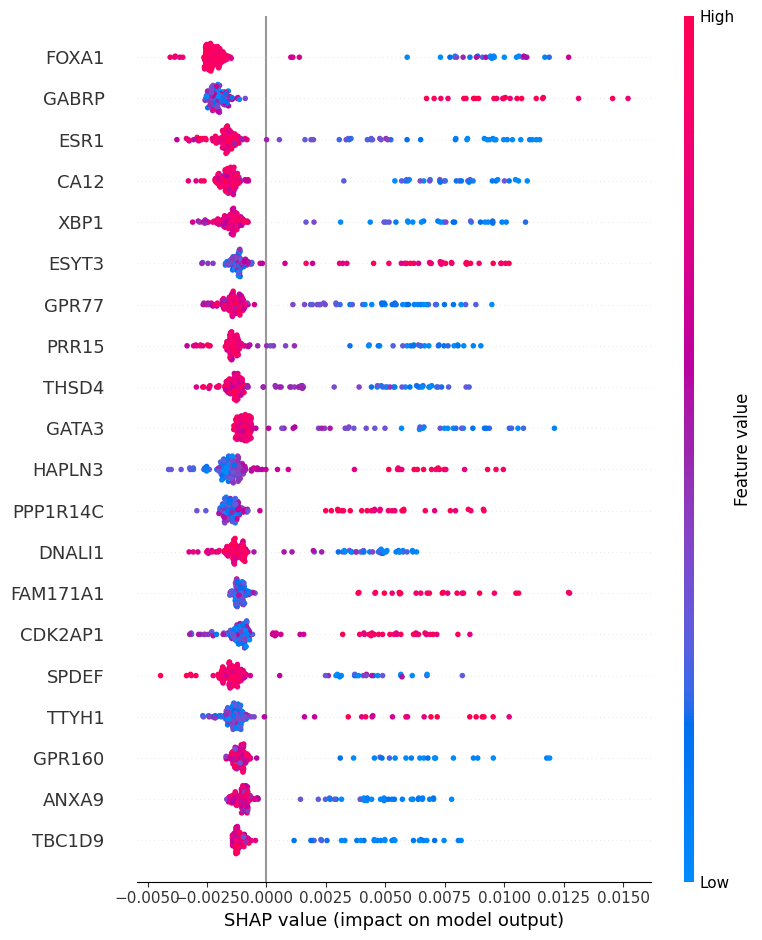

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    show=False
)

In [ ]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, "shape") else "No shape")

print(type(explainer))

<class 'numpy.ndarray'>
(149, 17030, 2)
<class 'shap.explainers._tree.TreeExplainer'>


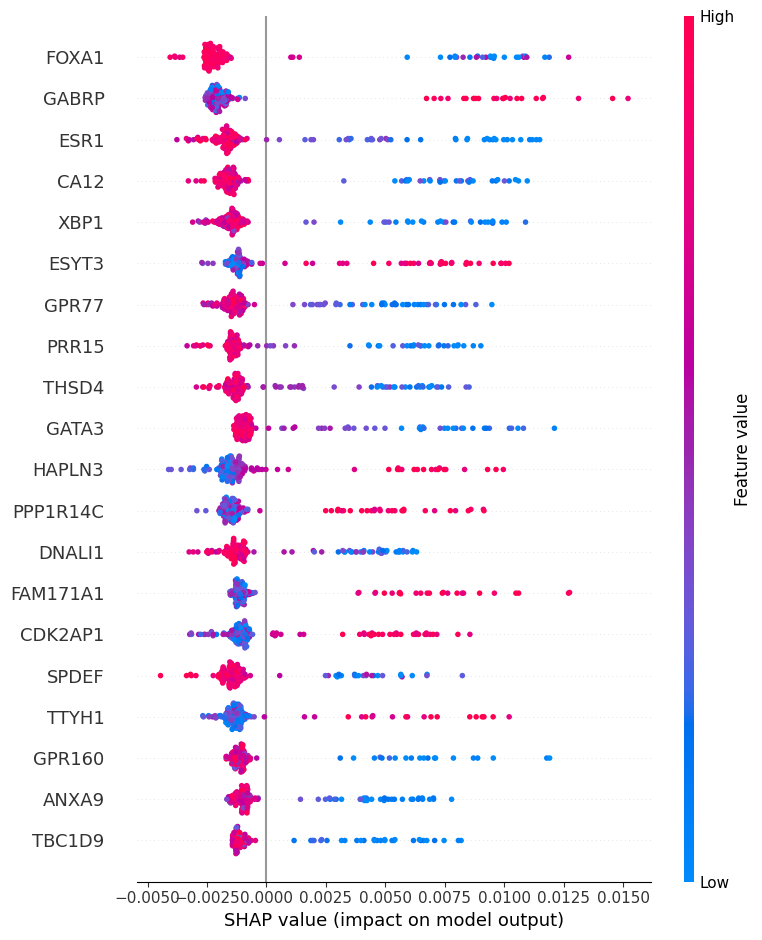

In [ ]:
# SHAP values for the TNBC class (class = 1)
shap_class1 = shap_values[:, :, 1]

plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_class1,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "Figure16_SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

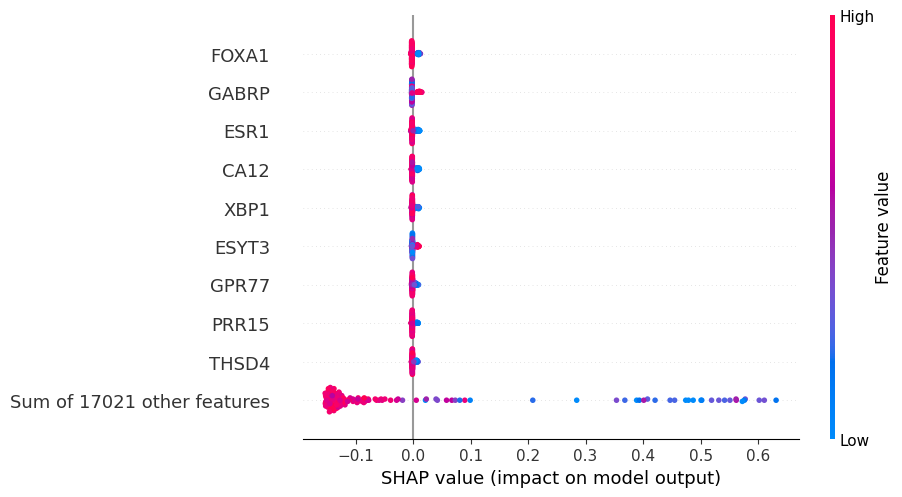

In [ ]:
shap.Explanation(
    values=shap_class1,
    base_values=explainer.expected_value[1],
    data=X_test.values,
    feature_names=X_test.columns
)

explanation = shap.Explanation(
    values=shap_class1,
    base_values=np.repeat(explainer.expected_value[1], len(X_test)),
    data=X_test.values,
    feature_names=X_test.columns
)

plt.figure(figsize=(12,8))

shap.plots.beeswarm(
    explanation,
    show=False
)

plt.savefig(
    "Figure17_SHAP_Beeswarm.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
importance = np.abs(shap_class1).mean(axis=0)

shap_df = pd.DataFrame({
    "Gene": X_test.columns,
    "Mean SHAP Value": importance
})

shap_df = shap_df.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

shap_df.head(20)

,Gene,Mean SHAP Value
12376,FOXA1,0.003556
3354,GABRP,0.003281
8285,ESR1,0.003011
4544,CA12,0.002951
8580,XBP1,0.002675
15147,ESYT3,0.002463
308,GPR77,0.002445
9692,PRR15,0.002322
111,THSD4,0.002235
11795,GATA3,0.002224


In [ ]:
importance = np.abs(shap_class1).mean(axis=0)

shap_df = pd.DataFrame({
    "Gene": X_test.columns,
    "Mean SHAP Value": importance
})

shap_df = shap_df.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

shap_df.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)

shap_df.head(20)

,Gene,Mean SHAP Value
12376,FOXA1,0.003556
3354,GABRP,0.003281
8285,ESR1,0.003011
4544,CA12,0.002951
8580,XBP1,0.002675
15147,ESYT3,0.002463
308,GPR77,0.002445
9692,PRR15,0.002322
111,THSD4,0.002235
11795,GATA3,0.002224


In [ ]:
import pandas as pd
import numpy as np

survival_results = pd.DataFrame({
    "Gene": [
        "ESR1",
        "FOXA1",
        "GATA3",
        "ERBB2",
        "AGR2",
        "AR",
        "XBP1",
        "FOXC1",
        "GRB7",
        "SOX10"
    ],
    "Hazard Ratio": [np.nan] * 10,
    "95% CI": [""] * 10,
    "Log-rank p-value": [np.nan] * 10,
    "Interpretation": [""] * 10
})

survival_results

,Gene,Hazard Ratio,95% CI,Log-rank p-value,Interpretation
0,ESR1,NaN,,NaN,
1,FOXA1,NaN,,NaN,
2,GATA3,NaN,,NaN,
3,ERBB2,NaN,,NaN,
4,AGR2,NaN,,NaN,
5,AR,NaN,,NaN,
6,XBP1,NaN,,NaN,
7,FOXC1,NaN,,NaN,
8,GRB7,NaN,,NaN,
9,SOX10,NaN,,NaN,


In [ ]:
survival_results.loc[survival_results["Gene"] == "ESR1", "Hazard Ratio"] = 0.64
survival_results.loc[survival_results["Gene"] == "ESR1", "95% CI"] = "0.58–0.71"
survival_results.loc[survival_results["Gene"] == "ESR1", "Log-rank p-value"] = "<1E-16"
survival_results.loc[survival_results["Gene"] == "ESR1", "Interpretation"] = "Better survival"

/tmp/ipykernel_2595/848651347.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<1E-16' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  survival_results.loc[survival_results["Gene"] == "ESR1", "Log-rank p-value"] = "<1E-16"


In [ ]:
survival_results.to_csv(
    "Survival_Analysis_Results.csv",
    index=False
)

In [ ]:
shap_class1 = shap_values[:, :, 1]

In [ ]:
import pandas as pd
import numpy as np

importance = np.abs(shap_class1).mean(axis=0)

shap_df = pd.DataFrame({
    "Gene": X_test.columns,
    "Mean SHAP Value": importance
})

shap_df = shap_df.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

shap_df.head(20)

,Gene,Mean SHAP Value
12376,FOXA1,0.003556
3354,GABRP,0.003281
8285,ESR1,0.003011
4544,CA12,0.002951
8580,XBP1,0.002675
15147,ESYT3,0.002463
308,GPR77,0.002445
9692,PRR15,0.002322
111,THSD4,0.002235
11795,GATA3,0.002224


In [ ]:
shap_df.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)

print("SHAP_Feature_Importance.csv created successfully!")

SHAP_Feature_Importance.csv created successfully!
